In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, matthews_corrcoef
from glob import glob
import re

In [3]:
from deconveil.utils_processing import *
from deconveil.utils_plot import *

#### Load simulated results

In [5]:
truth_df = pd.read_csv("sim_results/sim_res_fit/sim1/truth_S60_G5000_CNstrong_R1.csv")
res_naive = pd.read_csv("sim_results/sim_res_fit/sim1/res_CNnaive_S60_G5000_CNstrong_R1.csv")
res_aware = pd.read_csv("sim_results/sim_res_fit/sim1/res_CNaware_S60_G5000_CNstrong_R1.csv")
res_naive["method"] = "CN naive"
res_aware["method"] = "CN aware"
res_naive

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,padj_stageR,DE_confirmed,method
0,LAMP1,6.473587e+06,2.514547,0.112500,22.191890,4.113372e-109,5.863317e-107,7.313475e-109,1.0,CN naive
1,NDRG3,2.829307e+05,-0.182448,0.162571,-1.256471,2.089452e-01,3.508676e-01,3.714995e-01,0.0,CN naive
2,ATPSCKMT,5.598090e+04,-0.529518,0.166093,-3.247368,1.164779e-03,3.223006e-03,2.070948e-03,1.0,CN naive
3,KRR1P1,2.478506e+03,0.099070,0.321376,0.353951,7.233755e-01,8.381144e-01,NaN,0.0,CN naive
4,KLHDC9,3.416270e+04,0.198164,0.304721,0.713474,4.755527e-01,6.427119e-01,8.455212e-01,0.0,CN naive
...,...,...,...,...,...,...,...,...,...,...
4984,ABCA9-AS1,1.925939e+04,0.212947,0.181293,1.250407,2.111510e-01,3.537382e-01,3.754214e-01,0.0,CN naive
4985,SLC17A5,6.759742e+05,2.742325,0.153040,18.069921,5.499215e-73,2.663649e-71,9.777470e-73,1.0,CN naive
4986,PDE2A,1.026203e+06,0.805563,0.267687,3.364680,7.663261e-04,2.164893e-03,1.362509e-03,1.0,CN naive
4987,PARN,3.666006e+05,-0.314448,0.163978,-2.123397,3.372062e-02,7.427470e-02,5.995445e-02,0.0,CN naive


In [7]:
res_naive["is_DE_naive"] = res_naive["DE_confirmed"] == 1.0
res_aware["is_DE_aware"] = res_aware["DE_confirmed"] == 1.0
res_aware

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,padj_stageR,DE_confirmed,method,is_DE_aware
0,LAMP1,6.473587e+06,3.564105,0.026210,19.568433,2.873831e-85,2.312507e-83,5.109602e-85,1.0,CN aware,True
1,NDRG3,2.829307e+05,0.657650,0.135114,-8.466280,2.533545e-17,1.595942e-16,4.504582e-17,1.0,CN aware,True
2,ATPSCKMT,5.598090e+04,4.226270,0.199491,17.449046,3.500280e-68,1.728999e-66,6.223412e-68,1.0,CN aware,True
3,KRR1P1,2.478506e+03,0.087075,0.323577,0.353947,7.233787e-01,8.457783e-01,NaN,0.0,CN aware,False
4,KLHDC9,3.416270e+04,0.694508,0.309745,-3.139566,1.691984e-03,4.389656e-03,3.008307e-03,1.0,CN aware,True
...,...,...,...,...,...,...,...,...,...,...,...
4984,ABCA9-AS1,1.925939e+04,1.148950,0.185535,6.014507,1.804355e-09,7.144385e-09,3.208099e-09,1.0,CN aware,True
4985,SLC17A5,6.759742e+05,3.542548,0.097534,16.122977,1.759272e-58,5.699354e-57,3.127942e-58,1.0,CN aware,True
4986,PDE2A,1.026203e+06,1.727744,0.098321,-0.086319,9.312129e-01,9.662690e-01,1.000000e+00,0.0,CN aware,False
4987,PARN,3.666006e+05,0.813210,0.123771,-7.957460,1.756070e-15,1.001261e-14,3.122251e-15,1.0,CN aware,True


In [9]:
truth_df

,Unnamed: 0,class,beta1,cn_ratio_log2,truth_log2FC_aware,truth_log2FC_naive,empirical_log2FC_naive,empirical_log2FC_aware,DE_truth
0,LAMP1,DIG,1.562364,0.432959,2.254014,2.686974,2.472340,2.180516,True
1,NDRG3,DCG,-0.908125,1.317111,-1.310147,0.006964,-0.204055,-1.383646,True
2,ATPSCKMT,DCG,2.079442,-3.321928,3.000000,-0.321928,-0.532930,2.926502,True
3,KRR1P1,NEUTRAL,0.063328,0.137504,0.091363,0.228866,0.017865,0.017865,False
4,KLHDC9,DCG,-0.946880,1.369234,-1.366059,0.003174,-0.210671,-1.439558,True
...,...,...,...,...,...,...,...,...,...
4984,ABCA9-AS1,DCG,0.838878,-0.736966,1.210245,0.473280,0.262278,1.136747,True
4985,SLC17A5,DIG,1.727451,0.450661,2.492185,2.942846,2.731362,2.418687,True
4986,PDE2A,DSG,0.027940,1.087463,0.040309,1.127772,0.915854,-0.033189,False
4987,PARN,DCG,-0.886971,1.093109,-1.279629,-0.186520,-0.403459,-1.353127,True


In [117]:
res_naive.rename(columns={'is_DE_naive': 'isDE',
                         'Unnamed: 0': 'geneID'}, inplace=True)

res_aware.rename(columns={'is_DE_aware': 'isDE',
                         'Unnamed: 0': 'geneID'}, inplace=True)

In [121]:
res_joint = pd.concat([
    res_naive.add_suffix("_naive"),
    res_aware.add_suffix("_aware")
], axis=1)
res_joint

,geneID_naive,baseMean_naive,log2FoldChange_naive,lfcSE_naive,stat_naive,pvalue_naive,padj_naive,padj_stageR_naive,DE_confirmed_naive,method_naive,...,baseMean_aware,log2FoldChange_aware,lfcSE_aware,stat_aware,pvalue_aware,padj_aware,padj_stageR_aware,DE_confirmed_aware,method_aware,isDE_aware
0,ACTN1,2.109654e+06,0.019794,0.149795,0.258633,7.959182e-01,8.795894e-01,NaN,0.0,CN naive,...,2.109654e+06,1.939331,0.070856,0.258633,7.959182e-01,8.852397e-01,NaN,0.0,CN aware,False
1,RPL5P17,9.063455e+03,-0.334736,0.220012,-1.616955,1.058880e-01,2.051632e-01,NaN,0.0,CN naive,...,9.063455e+03,-0.230709,0.223151,-1.616943,1.058906e-01,2.045334e-01,NaN,0.0,CN aware,False
2,LRRC17,1.168969e+05,1.390622,0.279727,5.182479,2.189556e-07,8.798738e-07,3.927049e-07,1.0,CN naive,...,1.168969e+05,1.804312,0.232040,1.709589,8.734192e-02,1.729869e-01,1.566509e-01,0.0,CN aware,False
3,MRPS30-DT,5.992735e+04,0.067883,0.428223,0.187601,8.511894e-01,9.131638e-01,1.000000e+00,0.0,CN naive,...,5.992735e+04,0.896017,0.398022,-2.469083,1.354599e-02,3.203703e-02,2.429523e-02,1.0,CN aware,True
4,CRYBG3,5.544713e+05,1.264969,0.229970,5.653011,1.576611e-08,6.944596e-08,2.827710e-08,1.0,CN naive,...,5.544713e+05,1.648018,0.120051,-0.009693,9.922664e-01,9.940575e-01,1.000000e+00,0.0,CN aware,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4990,SP1,1.289511e+06,1.354012,0.177077,7.865512,3.675910e-15,2.406444e-14,6.592879e-15,1.0,CN naive,...,1.289511e+06,2.537606,0.082883,6.334853,2.375672e-10,1.068090e-09,4.260855e-10,1.0,CN aware,True
4991,NME9,6.921542e+03,1.138421,0.092550,12.384200,3.182419e-35,5.177910e-34,5.707786e-35,1.0,CN naive,...,6.921542e+03,-0.171421,0.091560,-1.192324,2.331344e-01,3.885573e-01,4.181351e-01,0.0,CN aware,False
4992,SRSF12,1.776849e+04,1.522657,0.112882,13.544626,8.524745e-42,1.723931e-40,1.528944e-41,1.0,CN naive,...,1.776849e+04,1.164097,0.112317,10.607017,2.764346e-26,2.900821e-25,4.957956e-26,1.0,CN aware,True
4993,P4HB,5.059676e+06,-0.159062,0.149359,-0.768855,4.419795e-01,6.127360e-01,7.927066e-01,0.0,CN naive,...,5.059676e+06,0.985703,0.037531,-8.126019,4.436189e-16,2.848170e-15,7.956468e-16,1.0,CN aware,True


Classification performance for DCG vs DSG and DCG vs DIG:

1) Add function 'classify genes' (DeConveil) 

2) Make binary confusion matrices:

- DCG (pos) vs DSG (neg) on gene classes ∈ {DCG,DSG}

- DCG (pos) vs DIG (neg) on gene classes ∈ {DCG,DIG}

#### DeConveil classificator: omnibus + stageR approach

In [123]:
def classify_genes(row):
    #alpha = 0.05  # FDR threshold

    de_naive = (row["DE_confirmed_naive"] == 1.0)
    de_aware = (row["DE_confirmed_aware"] == 1.0)

    if (not de_naive) and de_aware:
        return "DCG"

    if de_naive and (not de_aware):
        return "DSG"

    if de_naive and de_aware:
        return "DIG"

    return "NEUTRAL"

pred_class = res_joint.apply(classify_genes, axis=1)
true_class = truth_df["class"]      # NEUTRAL / DIG / DSG / DCG (simulator)
pred_class = pred_class             # NEUTRAL / DIG / DSG / DCG (DeConveil)


In [125]:
# Restrict to only DCG o DSG genes
mask_dcg_dsg = truth_df["class"].isin(["DCG", "DSG"])

true_sub  = truth_df["class"][mask_dcg_dsg]
pred_sub  = pred_class[mask_dcg_dsg]

y_true = (true_sub == "DCG")        # True se DCG, False se DSG
y_pred = (pred_sub == "DCG")        # modello chiama DCG?

# Confusion matrix and metrics

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[False, True]).ravel()

print("=== DCG vs DSG ===")
print(f"TP = {tp}  (DCG true correctly called DCG)")
print(f"FN = {fn}  (DCG true called DSG)")
print(f"FP = {fp}  (DSG true called DCG)")
print(f"TN = {tn}  (DSG true called non-DCG)")

print(classification_report(y_true, y_pred, target_names=["DSG (neg)", "DCG (pos)"]))

#TP + FN = number of genes really DCG (in simulator)
#FP + TN = number of genes really DSG

=== DCG vs DSG ===
TP = 519  (DCG true correctly called DCG)
FN = 231  (DCG true called DSG)
FP = 18  (DSG true called DCG)
TN = 731  (DSG true called non-DCG)
              precision    recall  f1-score   support

   DSG (neg)       0.76      0.98      0.85       749
   DCG (pos)       0.97      0.69      0.81       750

    accuracy                           0.83      1499
   macro avg       0.86      0.83      0.83      1499
weighted avg       0.86      0.83      0.83      1499



In [127]:
# DCG vs DIG

mask = truth_df["class"].isin(["DCG", "DIG"])
y_true = (truth_df.loc[mask, "class"] == "DCG").astype(int)

pred_is_dcg = (
    (~res_naive.loc[mask, "isDE"]) &
    (res_aware.loc[mask, "isDE"])
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    pred_is_dcg,
    labels=[0, 1]  # 0=DIG, 1=DCG
).ravel()

print("=== DCG vs DIG ===")
print(f"TP = {tp}  (DCG correctly classified)")
print(f"FN = {fn}  (DCG classified as DIG)")
print(f"FP = {fp}  (DIG classified as DCG)")
print(f"TN = {tn}  (DIG correctly classified)")

print("\nClassification report:")
print(classification_report(
    y_true, pred_is_dcg,
    target_names=["DIG (neg)", "DCG (pos)"]
))

=== DCG vs DIG ===
TP = 519  (DCG correctly classified)
FN = 231  (DCG classified as DIG)
FP = 51  (DIG classified as DCG)
TN = 1447  (DIG correctly classified)

Classification report:
              precision    recall  f1-score   support

   DIG (neg)       0.86      0.97      0.91      1498
   DCG (pos)       0.91      0.69      0.79       750

    accuracy                           0.87      2248
   macro avg       0.89      0.83      0.85      2248
weighted avg       0.88      0.87      0.87      2248



In [129]:
# DIG vs DSG
mask = truth_df["class"].isin(["DIG", "DSG"])

# True labels: 1 = DIG, 0 = DSG
y_true = (truth_df.loc[mask, "class"] == "DIG").astype(int)

# Prediction rule:
#   predict DIG (1) if both naive and aware call DE
#   otherwise classify as DSG (0)
pred_is_dig = (
    res_naive.loc[mask, "isDE"].astype(bool) &
    res_aware.loc[mask, "isDE"].astype(bool)
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    pred_is_dig,
    labels=[0, 1]  # 0=DSG, 1=DIG
).ravel()

print("=== DIG vs DSG ===")
print(f"TP = {tp}  (DIG correctly classified)")
print(f"FN = {fn}  (DIG classified as DSG)")
print(f"FP = {fp}  (DSG classified as DIG)")
print(f"TN = {tn}  (DSG correctly classified)")

print("\nClassification report:")
print(classification_report(
    y_true, pred_is_dig,
    target_names=["DSG (neg)", "DIG (pos)"]
))

=== DIG vs DSG ===
TP = 1294  (DIG correctly classified)
FN = 204  (DIG classified as DSG)
FP = 33  (DSG classified as DIG)
TN = 716  (DSG correctly classified)

Classification report:
              precision    recall  f1-score   support

   DSG (neg)       0.78      0.96      0.86       749
   DIG (pos)       0.98      0.86      0.92      1498

    accuracy                           0.89      2247
   macro avg       0.88      0.91      0.89      2247
weighted avg       0.91      0.89      0.90      2247



#### Simulation benchmarking
Simulation 1

In [29]:
# Load one simulation and compute metrics

def classify_deconveil(res_df):
    """
    Apply DeConveil decision tree to fitted results.
    Returns a pd.Series with predicted gene class.
    """
    # significance reference: Simes screening + stageR approach
    de_naive = res_df["DE_naive"] == 1.0
    de_aware = res_df["DE_aware"] == 1.0

    # significance reference (single source of truth): standard approach (BH for each test separately)
    #de_naive = res_df["padj_naive"] < 0.05
    #de_aware = res_df["padj_aware"] < 0.05

    pred = np.full(len(res_df), "NEUTRAL", dtype=object)

    pred[(~de_naive) & de_aware] = "DCG"
    pred[de_naive & (~de_aware)] = "DSG"
    pred[de_naive & de_aware] = "DIG"

    return pd.Series(pred, index=res_df.index, name="pred_class")
    

def parse_sim_filename(path):
    """
    Parse simulation metadata from filename.

    Expected pattern:
      *_S{sample}_G{genes}_CN{signal}_R{rep}.*
    """

    fname = os.path.basename(path)

    pattern = r"_S(\d+)_G(\d+)_CN([A-Za-z0-9]+)_R(\d+)"
    m = re.search(pattern, fname)

    if m is None:
        raise ValueError(f"Cannot parse metadata from filename: {fname}")

    sample_size = int(m.group(1))
    n_genes = int(m.group(2))
    cn_signal = m.group(3)
    replicate = int(m.group(4))

    return {
        "sample_size": sample_size,
        "n_genes": n_genes,
        "cn_signal": cn_signal,
        "replicate": replicate,
        # convenience tag for file matching
        "tag": f"S{sample_size}_G{n_genes}_CN{cn_signal}_R{replicate}"
    }

def binary_classification_metrics(
    truth_class,
    pred_class,
    pos_class,
    neg_class
):
    """
    Compute confusion matrix + metrics for pos vs neg.
    """

    mask = truth_class.isin([pos_class, neg_class])

    y_true = (truth_class[mask] == pos_class).astype(int)
    y_pred = (pred_class[mask] == pos_class).astype(int)

    # one-vs-rest binary coding
    #y_true = (truth_class == pos_class).astype(int)
    #y_pred = (pred_class == pos_class).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # Compute AUC — roc_auc_score requires at least one pos and neg label
    try:
        auc = roc_auc_score(y_true, y_pred)
    except ValueError:
        auc = np.nan

    # Compute MCC — requires at least one pos and one neg prediction
    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except ValueError:
        mcc = np.nan

    metrics = {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        "Recall": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        "F1 score": 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else np.nan,
        "Accuracy": (tp + tn) / (tp + tn + fp + fn),
        "AUC": auc,
        "MCC": mcc,
        "n_pos": (truth_class == pos_class).sum(),
        "n_neg": (truth_class == neg_class).sum(), # pair-wise comparison
        #"n_neg": (truth_class != pos_class).sum(),
    }

    return metrics

# Benchmark one simulation replicate
def benchmark_one_sim(truth_df, res_naive, res_aware, sim_meta):

    res = truth_df.copy()

    res = res.join(
        res_naive[["DE_confirmed", "padj"]].rename(
            columns={"DE_confirmed": "DE_naive", "padj": "padj_naive"}
        )
    )

    res = res.join(
        res_aware[["DE_confirmed", "padj"]].rename(
            columns={"DE_confirmed": "DE_aware", "padj": "padj_aware"}
        )
    )

    res["pred_class"] = classify_deconveil(res)

    results = []

    for pos, neg in [("DCG", "DSG"), ("DCG", "DIG")]:
    #for pos in ["DCG", "DSG", "DIG"]:
        m = binary_classification_metrics(
            truth_class=res["class"],
            pred_class=res["pred_class"],
            pos_class=pos,
            neg_class=neg,
        )
        results.append({
            **sim_meta,
            "comparison": f"{pos}_vs_{neg}",
            #"comparison": f"{pos}_vs_rest",
            **m
        })

    return pd.DataFrame(results)
    

# Benchmark all replicates
def benchmark_all_sims(
    truth_dir,
    fit_dir,
    alpha=0.05,
):
    all_results = []

    truth_files = sorted(glob(os.path.join(truth_dir, "truth_*.csv")))

    for tf in truth_files:
        meta = parse_sim_filename(tf)  
        # should return dict with sample_size, cn_signal, replicate

        truth_df = pd.read_csv(tf, index_col=0)

        res_naive = pd.read_csv(
            os.path.join(fit_dir, f"res_CNnaive_{meta['tag']}.csv"),
            index_col=0
        )
        res_aware = pd.read_csv(
            os.path.join(fit_dir, f"res_CNaware_{meta['tag']}.csv"),
            index_col=0
        )

        df = benchmark_one_sim(
            truth_df,
            res_naive,
            res_aware,
            sim_meta=meta,
        )

        all_results.append(df)

    return pd.concat(all_results, ignore_index=True)

In [45]:
truth_dir = "sim_results/sim_res_fit/sim1/"
fit_dir = "sim_results/sim_res_fit/sim1/"

all_res_sim1 = benchmark_all_sims(truth_dir=truth_dir,
                             fit_dir=fit_dir)

In [47]:
all_res_sim1

,sample_size,n_genes,cn_signal,replicate,tag,comparison,TP,FP,FN,TN,Precision,Recall,F1 score,Accuracy,AUC,MCC,n_pos,n_neg
0,10,5000,strong,1,S10_G5000_CNstrong_R1,DCG_vs_DSG,363,33,387,715,0.916667,0.484000,0.633508,0.719626,0.719941,0.498746,750,748
1,10,5000,strong,1,S10_G5000_CNstrong_R1,DCG_vs_DIG,363,80,387,1416,0.819413,0.484000,0.608550,0.792075,0.715262,0.510263,750,1496
2,10,5000,strong,10,S10_G5000_CNstrong_R10,DCG_vs_DSG,347,26,402,722,0.930295,0.463284,0.618538,0.714095,0.714263,0.495371,749,748
3,10,5000,strong,10,S10_G5000_CNstrong_R10,DCG_vs_DIG,347,87,402,1409,0.799539,0.463284,0.586644,0.782183,0.702565,0.483722,749,1496
4,10,5000,strong,13,S10_G5000_CNstrong_R13,DCG_vs_DSG,331,21,419,727,0.940341,0.441333,0.600726,0.706275,0.706629,0.487348,750,748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,60,5000,weak,7,S60_G5000_CNweak_R7,DCG_vs_DIG,361,53,389,1443,0.871981,0.481333,0.620275,0.803206,0.722953,0.542346,750,1496
276,60,5000,weak,8,S60_G5000_CNweak_R8,DCG_vs_DSG,371,13,378,735,0.966146,0.495327,0.654898,0.738811,0.738974,0.547216,749,748
277,60,5000,weak,8,S60_G5000_CNweak_R8,DCG_vs_DIG,371,49,378,1447,0.883333,0.495327,0.634731,0.809800,0.731287,0.559282,749,1496
278,60,5000,weak,9,S60_G5000_CNweak_R9,DCG_vs_DSG,349,20,401,728,0.945799,0.465333,0.623771,0.718959,0.719298,0.508962,750,748


In [49]:
all_res_sim1.to_csv("sim_results/data_to_plot/performance_data_stageR_pairwise.csv", index=True)

In [79]:
# Long format
metrics = ["F1 score", "Accuracy", "AUC"]

plot_df = all_res.melt(
    id_vars=["sample_size", "cn_signal", "comparison"],
    value_vars=metrics,
    var_name="metric",
    value_name="value"
)

In [81]:
# Plot

def plot_performance_boxplots(
    df,
    comparison,
    outpath=None,
):
    sub = df[df["comparison"] == comparison]

    g = sns.catplot(
        data=sub,
        x="sample_size",
        y="value",
        hue="cn_signal",
        col="metric",
        kind="box",
        col_wrap=3,
        sharey=True,
        height=4,
        aspect=1,
        linewidth=1.5,
        fill=False,                  # no fill
        palette={"weak": "#4C72B0", "strong": "#DD8452"},
    )

    for ax in g.axes.flatten():
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

    g.set_axis_labels("Samples per condition", "Metric value")
    g.set_titles("{col_name}")
    g.fig.suptitle(
        f"{comparison.replace('_', ' ')}",
        y=1.05,
        fontsize=14
    )

    if outpath is not None:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")

    plt.show()

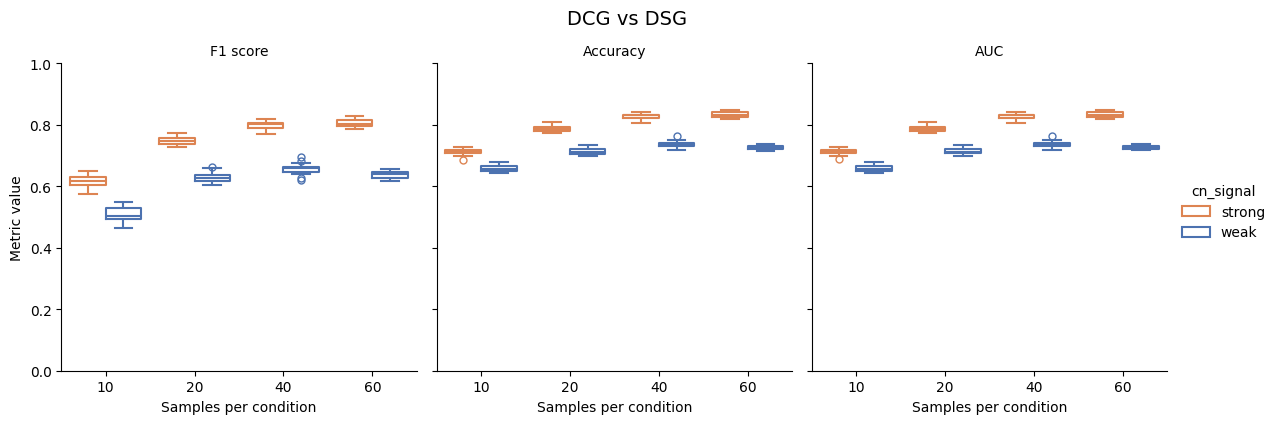

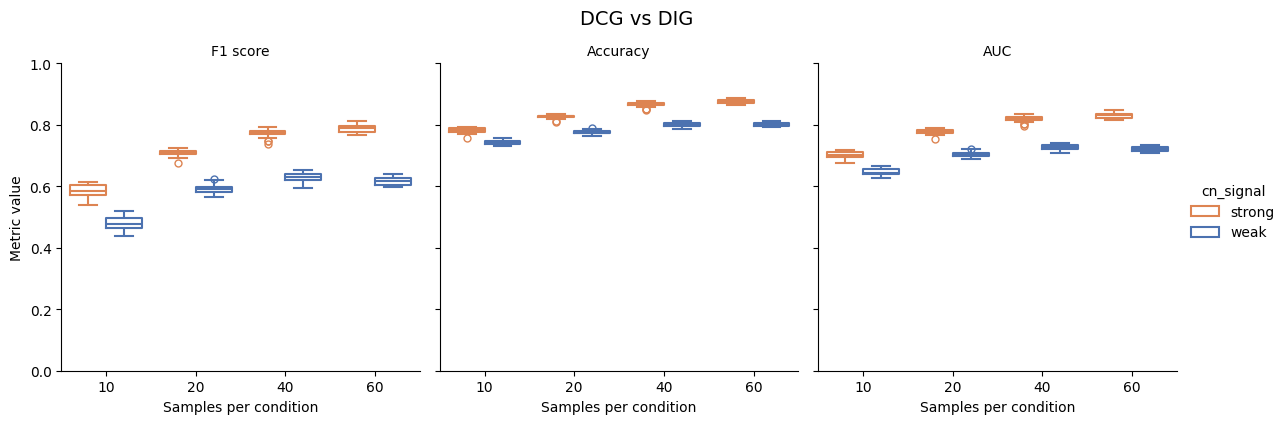

In [29]:
plot_performance_boxplots(
    plot_df,
    comparison="DCG_vs_DSG",
    outpath="plots/boxplot_DCG_vs_DSG.png",
)

plot_performance_boxplots(
    plot_df,
    comparison="DCG_vs_DIG",
    outpath="plots/boxplot_DCG_vs_DIG.png",
)

Simulation 2

In [31]:
# Binary DE metrics
def binary_de_metrics(y_true, y_pred):
    """
    Binary DE detection metrics.
    """

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    try:
        auc = roc_auc_score(y_true, y_pred)
    except ValueError:
        auc = np.nan

    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except ValueError:
        mcc = np.nan

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        "Recall": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        "F1": 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else np.nan,
        "Accuracy": (tp + tn) / (tp + tn + fp + fn),
        "AUC": auc,
        "MCC": mcc,
        "n_pos": int(y_true.sum()),
        "n_neg": int((y_true == 0).sum()),
    }


# Benchmark one simulation replicate
def benchmark_one_sim(truth_df, res_naive, res_aware, sim_meta, alpha=0.05):

    # Keep only DIG, DSG, NEUTRAL
    truth_df = truth_df[truth_df["class"].isin(["DIG", "DSG", "NEUTRAL"])]

    # Align all dataframes by gene index
    common_idx = (
        truth_df.index
        .intersection(res_naive.index)
        .intersection(res_aware.index)
    )

    truth_df = truth_df.loc[common_idx]
    res_naive = res_naive.loc[common_idx]
    res_aware = res_aware.loc[common_idx]

    # Binary ground truth
    y_true = truth_df["DE_truth"].astype(int)

    # Predictions
    #y_pred_naive = (res_naive["padj"] < alpha).astype(int)
    #y_pred_aware = (res_aware["padj"] < alpha).astype(int)

    y_pred_naive = res_naive["DE_confirmed"] == 1.0
    y_pred_aware = res_aware["DE_confirmed"] == 1.0

    results = []

    for method, y_pred in {
        "PyDESeq2": y_pred_naive,
        "DeConveil": y_pred_aware
    }.items():

        m = binary_de_metrics(y_true, y_pred)

        # FP decomposition
        fp_dsg = (
            (y_true == 0)
            & (truth_df["class"] == "DSG")
            & (y_pred == 1)
        ).sum()

        fp_neutral = (
            (y_true == 0)
            & (truth_df["class"] == "NEUTRAL")
            & (y_pred == 1)
        ).sum()

        results.append({
            **sim_meta,
            "method": method,
            **m,
            "FP_DSG": fp_dsg,
            "FP_NEUTRAL": fp_neutral,
        })

    return pd.DataFrame(results)

# Benchmark all replicates
def benchmark_all_sims(
    truth_dir,
    fit_dir,
    alpha=0.05,
):
    all_results = []

    truth_files = sorted(glob(os.path.join(truth_dir, "truth_*.csv")))

    for tf in truth_files:
        meta = parse_sim_filename(tf)

        truth_df = pd.read_csv(tf, index_col=0)

        res_naive = pd.read_csv(
            os.path.join(fit_dir, f"res_CNnaive_{meta['tag']}.csv"),
            index_col=0
        )

        res_aware = pd.read_csv(
            os.path.join(fit_dir, f"res_CNaware_{meta['tag']}.csv"),
            index_col=0
        )

        df = benchmark_one_sim(
            truth_df,
            res_naive,
            res_aware,
            sim_meta=meta,
            alpha=alpha
        )

        all_results.append(df)

    return pd.concat(all_results, ignore_index=True)

In [33]:
truth_dir = "sim_results/sim_res_fit/sim2"
fit_dir = "sim_results/sim_res_fit/sim2/"

all_res_sim2 = benchmark_all_sims(truth_dir=truth_dir,
                             fit_dir=fit_dir)

In [35]:
all_res_sim2

,sample_size,n_genes,cn_signal,replicate,tag,method,TP,FP,FN,TN,Precision,Recall,F1,Accuracy,AUC,MCC,n_pos,n_neg,FP_DSG,FP_NEUTRAL
0,10,5000,strong,1,S10_G5000_CNstrong_R1,PyDESeq2,819,275,680,2717,0.748629,0.546364,0.631701,0.787352,0.727226,0.499245,1499,2992,195,80
1,10,5000,strong,1,S10_G5000_CNstrong_R1,DeConveil,871,160,628,2832,0.844811,0.581054,0.688538,0.824538,0.763789,0.591563,1499,2992,22,138
2,10,5000,strong,10,S10_G5000_CNstrong_R10,PyDESeq2,811,264,693,2728,0.754419,0.539229,0.628926,0.787144,0.725497,0.498878,1504,2992,171,93
3,10,5000,strong,10,S10_G5000_CNstrong_R10,DeConveil,853,148,651,2844,0.852148,0.567154,0.681038,0.822286,0.758845,0.587128,1504,2992,22,126
4,10,5000,strong,11,S10_G5000_CNstrong_R11,PyDESeq2,896,255,604,2736,0.778454,0.597333,0.675971,0.808729,0.756039,0.553196,1500,2991,172,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,60,5000,weak,7,S60_G5000_CNweak_R7,DeConveil,1372,140,132,2843,0.907407,0.912234,0.909814,0.939380,0.932651,0.864169,1504,2983,30,110
316,60,5000,weak,8,S60_G5000_CNweak_R8,PyDESeq2,1314,413,189,2575,0.760857,0.874251,0.813622,0.865954,0.868016,0.713923,1503,2988,326,87
317,60,5000,weak,8,S60_G5000_CNweak_R8,DeConveil,1348,144,155,2844,0.903485,0.896873,0.900167,0.933422,0.924340,0.850239,1503,2988,24,120
318,60,5000,weak,9,S60_G5000_CNweak_R9,PyDESeq2,1347,406,153,2582,0.768397,0.898000,0.828159,0.875446,0.881062,0.736871,1500,2988,335,71


In [37]:
all_res_sim2.to_csv("sim_results/data_to_plot/performance_data_stageR_sim2.csv", index=True)

#### Plot confusion matrices

DSG vs others
DCG vs others
DIG vs others

In [9]:
# Load one replicate per setting

def load_single_rep(truth_dir, fit_dir, S, CN, R):
    truth_file = f"truth_S{S}_G5000_CN{CN}_R{R}.csv"
    naive_file = f"res_CNnaive_S{S}_G5000_CN{CN}_R{R}.csv"
    aware_file = f"res_CNaware_S{S}_G5000_CN{CN}_R{R}.csv"

    truth_df = pd.read_csv(os.path.join(truth_dir, truth_file), index_col=0)
    naive_df = pd.read_csv(os.path.join(fit_dir, naive_file), index_col=0)
    aware_df = pd.read_csv(os.path.join(fit_dir, aware_file), index_col=0)

    # ensure aligned index order
    naive_df = naive_df.loc[truth_df.index]
    aware_df = aware_df.loc[truth_df.index]

    return truth_df, naive_df, aware_df
    

def classify_deconveil(truth_df, naive_df, aware_df):
    """
    Apply DeConveil decision tree using DE_confirmed flags.
    Logic identical to reference implementation.
    """

    # safety checks
    assert truth_df.index.equals(naive_df.index)
    assert truth_df.index.equals(aware_df.index)

    df = pd.DataFrame(index=truth_df.index)
    df["truth_class"] = truth_df["class"]

    # significance reference: omnibus+stageR approach
    #df["DE_naive"] = naive_df["DE_confirmed"] == 1
    #df["DE_aware"] = aware_df["DE_confirmed"] == 1

    # significance reference (single source of truth): standard approach (BH for each test separately)
    df["DE_naive"] = naive_df["padj"] < 0.05
    df["DE_aware"] = aware_df["padj"] < 0.05

    # identical logic to reference
    pred = np.full(len(df), "NEUTRAL", dtype=object)

    pred[(~df["DE_naive"]) & df["DE_aware"]] = "DCG"
    pred[df["DE_naive"] & (~df["DE_aware"])] = "DSG"
    pred[df["DE_naive"] & df["DE_aware"]] = "DIG"

    df["predicted_class"] = pred

    return df


# One-vs-rest confusion matrix

def confusion_one_class(df, target_class):

    y_true = (df["truth_class"] == target_class).astype(int)
    y_pred = (df["predicted_class"] == target_class).astype(int)

    if y_true.sum() == 0:
        return None  # no true positives possible

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return pd.DataFrame(
        [[tp, fn],
         [fp, tn]],
        index=[f"True {target_class}", "True other"],
        columns=[f"Pred {target_class}", "Pred other"]
    )


def plot_confusion_heatmap(cm_df, title, ax):

    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        linewidths=1,
        linecolor="black",
        square=True,
        ax=ax
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")



def plot_all_classes_confusion(
    merged_df, S, CN, R, savepath=None
):

    classes = ["DCG", "DSG", "DIG"]
    fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))

    for ax, cls in zip(axes, classes):
        cm_df = confusion_one_class(merged_df, cls)

        if cm_df is None:
            ax.axis("off")
            ax.set_title(f"{cls}\n(no true genes)")
            continue

        plot_confusion_heatmap(
            cm_df,
            title=f"{cls} vs others\nS={S}, CN={CN}",
            ax=ax
        )

    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=400)
        plt.close()
    else:
        plt.show()


In [11]:
for S in [20, 60]:
    truth_df, naive_df, aware_df = load_single_rep(
        truth_dir="sim_results/sim_res_fit/",
        fit_dir="sim_results/sim_res_fit/",
        S=S,
        CN="strong",
        R=2
    )

    merged = classify_deconveil(truth_df, naive_df, aware_df)
    # add metadata
    merged = merged.assign(
        sample_size=S,
        cn_signal="strong",
        replicate=2
    )

    outpath = f"sim_results/data_to_plot/merged_S{S}_CNstrong_R2_standard.csv"
    merged.to_csv(outpath)

    plot_all_classes_confusion(
        merged_df=merged,
        S=S,
        CN="strong",
        R=2,
        savepath=f"plots/confusion_S{S}_CNstrong_r2_standard.png"
    )

#### Null simulation analysis

In [65]:
all_p = pd.read_csv("sim_results/sim_null/null_pval_all.csv")
all_p.head()

,Unnamed: 0,p_naive,p_aware,sample_size,rep
0,0,0.557375,0.557375,10,0
1,1,0.141976,0.141979,10,0
2,2,0.931048,0.931050,10,0
3,3,0.590662,0.590670,10,0
4,4,0.638442,0.638441,10,0


In [67]:
all_p = all_p.drop(columns=["Unnamed: 0"], errors="ignore")
df_long = all_p.melt(
    id_vars=["sample_size", "rep"],
    value_vars=["p_naive", "p_aware"],
    var_name="model",
    value_name="p_value"
)
df_long["model"] = df_long["model"].str.replace("p_", "CN-")
df_long

,sample_size,rep,model,p_value
0,10,0,CN-naive,0.557375
1,10,0,CN-naive,0.141976
2,10,0,CN-naive,0.931048
3,10,0,CN-naive,0.590662
4,10,0,CN-naive,0.638442
...,...,...,...,...
399227,60,9,CN-aware,0.611633
399228,60,9,CN-aware,0.467853
399229,60,9,CN-aware,0.700941
399230,60,9,CN-aware,0.569458


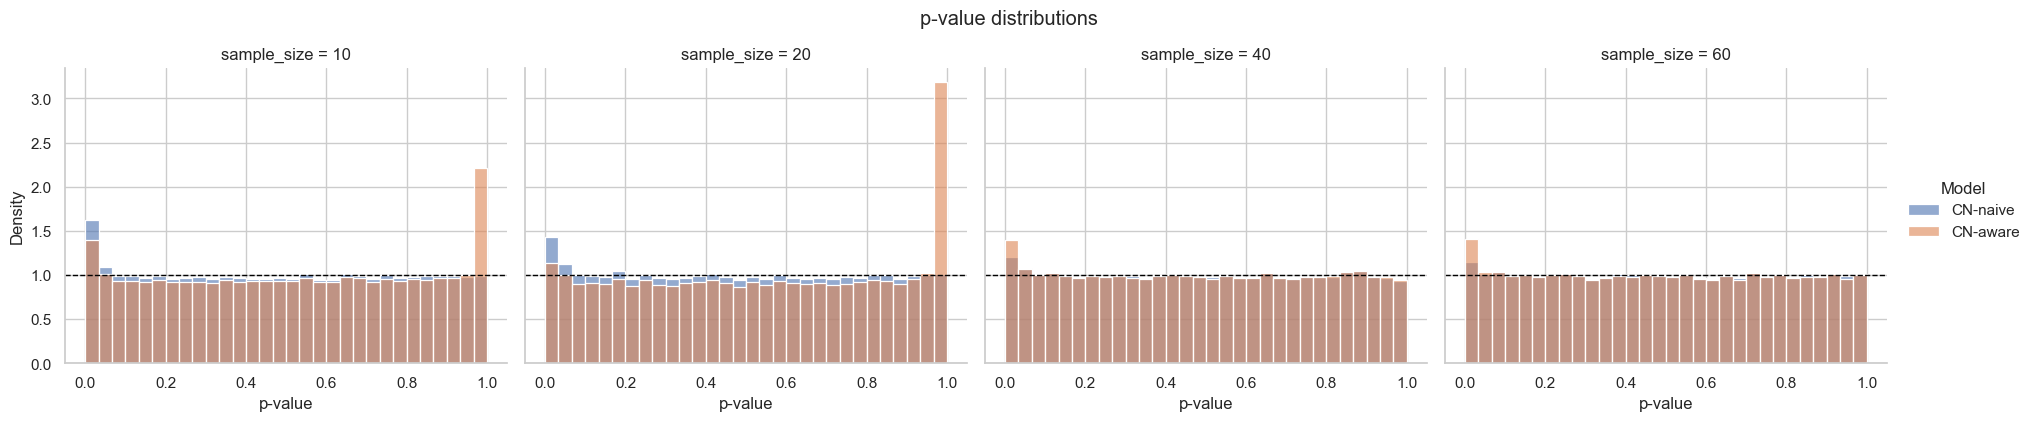

In [43]:
sns.set(style="whitegrid")

g = sns.FacetGrid(
    df_long,
    col="sample_size",
    hue="model",
    col_wrap=4,          # adjust based on number of sample sizes
    height=4,
    aspect=1.2,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.histplot,
    x="p_value",
    bins=30,
    stat="density",
    common_norm=False,
    alpha=0.6
)

# Reference line for Uniform(0,1)
for ax in g.axes.flat:
    ax.axhline(1, linestyle="--", color="black", linewidth=1)

g.set_axis_labels("p-value", "Density")
g.add_legend(title="Model")
g.fig.suptitle("p-value distributions", y=1.05)

plt.show()

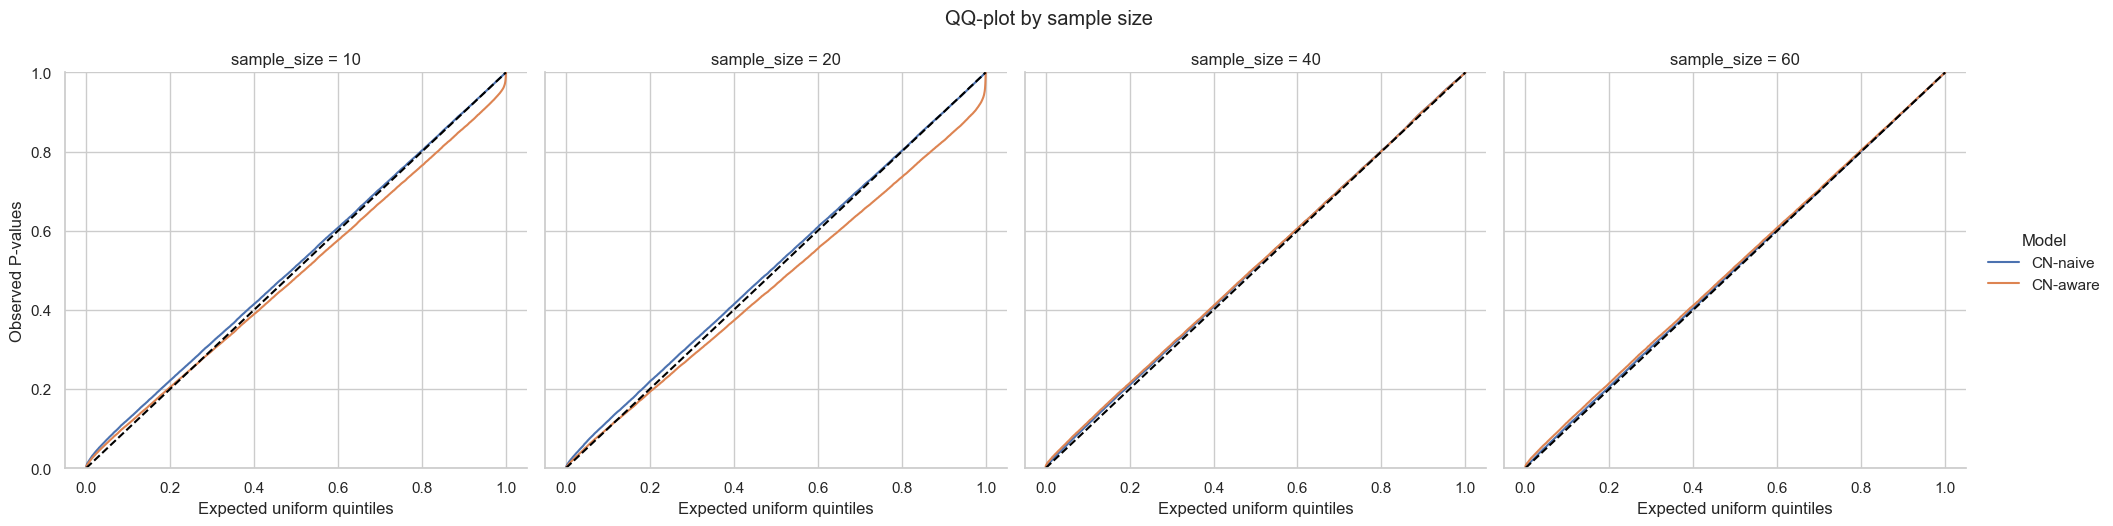

In [63]:
g = sns.FacetGrid(
    df_long,
    col="sample_size",
    hue="model",
    col_wrap=4,
    height=5,
    aspect=1.0,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.ecdfplot,
    x="p_value"
)

# Uniform(0,1) reference line
for ax in g.axes.flat:
    ax.plot([0, 1], [0, 1], linestyle="--", color="black")

g.set_axis_labels("Expected uniform quintiles", "Observed P-values")
g.add_legend(title="Model")
g.fig.suptitle("QQ-plot by sample size", y=1.05)

plt.show()

In [69]:
df_long.to_csv("sim_results/data_to_plot/pval_null.csv", index=True)